In [1]:
import numpy as np
import os
import matplotlib.pyplot as plt

import h5py
import sys
sys.path.append('../')
import analysis_utils as utils

from scipy.signal import decimate

utils.load_plotting_setting()

In [2]:
c_mv = 8.263269630174246e-08
amp2kev = 7157.624533259538
sigma_p = 176.79818534573002

sigma_amp = sigma_p / amp2kev

In [3]:
def get_normalized_template(sphere, voltage, bounds=(1000, 2000), downsampled=False):
    # pulse_shape_file = np.load(rf'/Users/yuhan/work/nanospheres/dm_nanospheres/data_processed/pulse_shape/{sphere}_pulse_shape_template_{voltage}v.npz')
    pulse_shape_file = np.load(rf'C:\Users\yuhan\dm_nanospheres\data_processed\pulse_shape\{sphere}_pulse_shape_template_{voltage}v.npz')

    pulse_shapes = pulse_shape_file['pulse_shape']
    pulse_shape_template = np.mean(pulse_shapes, axis=0)

    normalized_template = pulse_shape_template / np.max(pulse_shape_template)

     # Take the central values around the peak
    ret = normalized_template[bounds[0]:bounds[1]]

    # Downsample to 500 kHz (so the 200 us template has 100 indices)
    if downsampled:
        ret_downsampled = decimate(ret, 10)
        return ret_downsampled / np.max(ret_downsampled)
    else:
        return ret

In [4]:
sphere_0 = 'sphere_20241202'
datasets_0 = [
            '20241202_8e-8mbar_long',
            '20241204_2e-8mbar_8e_aftercal_long',
            '20241205_2e-8mbar_0e_aftercal_long',
            '20241206_1e-8mbar_0e_aftercal_long',
            '20241207_1e-8mbar_1e_aftercal_long',
            '20241208_1e-8mbar_1e_aftercal_long',
            '20241210_1e-8mbar_8e_alignment1_long',
            '20241210_1e-8mbar_8e_alignment2_long_withdrive',
            '20241210_1e-8mbar_8e_alignment2_long_nodrive',
            '20241211_1e-8mbar_8e_alignment2_long_nodrive',
            '20241212_1e-8mbar_8e_alignment2_long_nodrive',
            '20241213_1e-8mbar_0e_alignment2_long',
            '20241214_1e-8mbar_0e_alignment2_long',
            '20241215_9e-9mbar_0e_alignment2_long',
            '20241216_5e-8mbar_0e_alignment2_long',
            '20241217_6e-8mbar_0e_alignment3_long',
            ]
data_prefixs_0 = [
                '20241202_abcd_',
                '20241204_abcd_',
                '20241205_d_',
                '20241206_d_',
                '20241207_d_',
                '20241208_d_',
                '20241210_d_',
                '20241210_d_',
                '20241210_d_',
                '20241211_d_',
                '20241212_d_',
                '20241213_d_',
                '20241214_d_',
                '20241215_d_',
                '20241216_d_',
                '20241217_d_',
                ]
n_files_0 = [1440, 1440, 1440, 1440, 1440, 821, 640, 181, 1440, 1418, 917, 1169, 1565, 1440, 1164, 601]

sphere_1 = 'sphere_20250103'
datasets_1 = [
            '20250104_4e-8mbar_alignment0_long',
            '20250105_2e-8mbar_alignment0_long',
            '20250106_2e-8mbar_8e_alignment0_long',
            '20250107_1e-8mbar_8e_alignment0_long',
            '20250108_1e-8mbar_8e_alignment0_long',
            '20250109_1e-8mbar_8e_alignment1_long',
            '20250110_1e-8mbar_8e_alignment1_long',
            '20250111_1e-8mbar_8e_alignment1_long',
            '20250112_9e-9mbar_8e_alignment1_long',
            '20250113_5e-8mbar_8e_alignment1_long',
            '20250114_1e-8mbar_1e_alignment1_long',
            '20250115_8e-9mbar_0e_alignment1_long',
            '20250116_8e-9mbar_0e_alignment1_long_wrong_lo',
            '20250117_8e-9mbar_0e_alignment1_long',
            '20250118_8e-9mbar_1e_alignment1_long',
            '20250120_8e-9mbar_1e_alignment1_long_wbackscat',
            '20250121_8e-9mbar_1e_alignment1_long',
            '20250122_8e-9mbar_1e_alignment1_long',
            '20250123_7e-9mbar_1e_alignment1_long',
            '20250124_7e-9mbar_1e_alignment1_long',
            '20250125_7e-9mbar_1e_alignment1_long'    
        ]
data_prefixs_1 = [
                '20250104_d_',
                '20250105_d_',
                '20250106_d_',
                '20250107_d_',
                '20250108_d_',
                '20250109_d_',
                '20250110_d_',
                '20250111_d_',
                '20250112_d_',
                '20250113_d_',
                '20250114_d_',
                '20250115_d_',
                '20250116_d_',
                '20250117_d_',
                '20250118_d_',
                '20250120_d_',
                '20250121_d_',
                '20250122_d_',
                '20250123_d_',
                '20250124_d_',
                '20250125_d_',
                ]
n_files_1 = [1440, 900, 1440, 1440, 1440, 1440, 1440, 1440, 780, 1440, 1440, 1440, 1440, 1440, 1983, 
           1463, 1440, 1440, 1440, 1440, 1121]

#### Noise level count for all datasets

Set the cut threshold to be 250 keV/c.

In [64]:
bins = np.arange(0, 1000, 10)
hh_noise_all_0, hh_noise_all_1 = np.zeros(bins.size-1, dtype=np.int64), np.zeros(bins.size-1, dtype=np.int64)

sphere = sphere_0
for dataset in datasets_0:
    data_dir = rf'E:\dm_data_processed_amp_chisquare\{sphere}\{dataset}'
    noise_file = np.load(rf'{data_dir}\{dataset}_noise_level_all.npz')

    bins = noise_file['bins']
    hh_noise_kev = noise_file['hh_noise_kev']
    
    hh_noise_all_0 += hh_noise_kev

sphere = sphere_1
for dataset in datasets_1:
    data_dir = rf'E:\dm_data_processed_amp_chisquare\{sphere}\{dataset}'
    noise_file = np.load(rf'{data_dir}\{dataset}_noise_level_all.npz')

    bins = noise_file['bins']
    hh_noise_kev = noise_file['hh_noise_kev']
    
    hh_noise_all_1 += hh_noise_kev


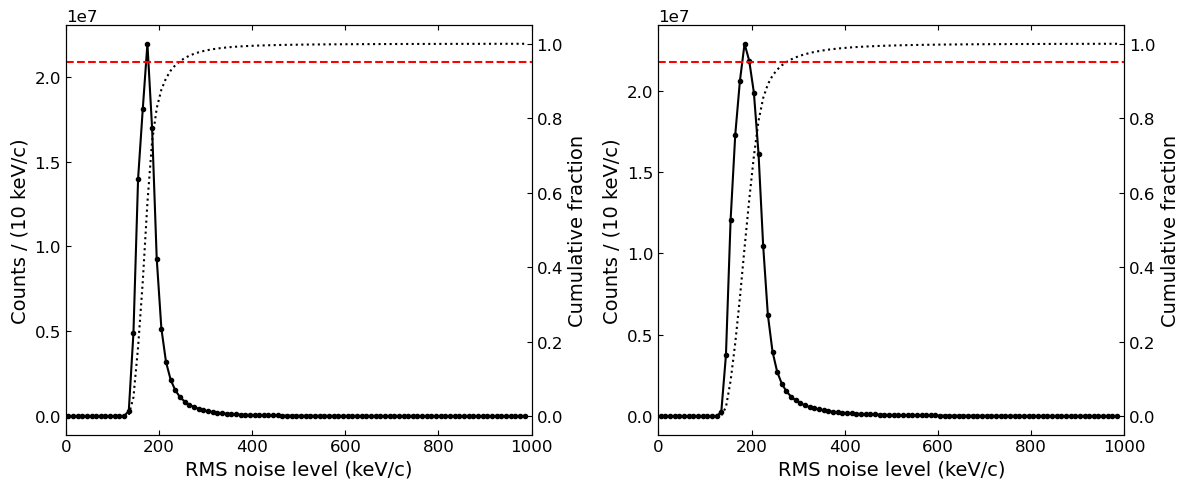

In [77]:
bc = 0.5 * (bins[1:] + bins[:-1])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(bc, hh_noise_all_0, 'k.-')
axes[1].plot(bc, hh_noise_all_1, 'k.-')

ax0_twinx = axes[0].twinx()
ax0_twinx.plot(bc, np.cumsum(hh_noise_all_0)/np.cumsum(hh_noise_all_0)[-1], 'k:')

ax1_twinx = axes[1].twinx()
ax1_twinx.plot(bc, np.cumsum(hh_noise_all_1)/np.cumsum(hh_noise_all_1)[-1], 'k:')

for ax in axes:
    ax.set_ylabel('Counts / (10 keV/c)')
    ax.set_xlabel('RMS noise level (keV/c)')
    ax.set_xlim(0, 1000)

for ax in [ax0_twinx, ax1_twinx]:
    ax.hlines(0.95, 0, 1000, 'r', linestyle='--')
    ax.set_ylabel('Cumulative fraction')

fig.tight_layout()

## $\chi^2$ test

In [5]:
bins_amp  = np.arange(0, 10000, 50)
bins_chi2 = np.arange(0, 10000, 10)
hh_amp_chi2_all_0, hh_amp_chi2_all_1 = np.zeros((bins_amp.size-1, bins_chi2.size-1), dtype=np.float64), np.zeros((bins_amp.size-1, bins_chi2.size-1), dtype=np.float64)

sphere = sphere_0
for dataset in datasets_0:
    data_dir = rf'E:\dm_data_processed_amp_chisquare\{sphere}\{dataset}'
    noise_file = np.load(rf'{data_dir}\{dataset}_amp_chi2_all.npz')
    hh_amp_chi2 = noise_file['hh_amp_chi2']
    hh_amp_chi2_all_0 += hh_amp_chi2

sphere = sphere_1
for dataset in datasets_1:
    data_dir = rf'E:\dm_data_processed_amp_chisquare\{sphere}\{dataset}'
    noise_file = np.load(rf'{data_dir}\{dataset}_amp_chi2_all.npz')
    hh_amp_chi2 = noise_file['hh_amp_chi2']
    hh_amp_chi2_all_1 += hh_amp_chi2


C:\Users\yuhan\AppData\Local\Temp\ipykernel_3180\781326827.py:3: RuntimeWarning: divide by zero encountered in log
  pc0 = axes[0].pcolormesh(bins_amp, bins_chi2, np.log(hh_amp_chi2_all_0.T))
C:\Users\yuhan\AppData\Local\Temp\ipykernel_3180\781326827.py:4: RuntimeWarning: divide by zero encountered in log
  pc1 = axes[1].pcolormesh(bins_amp, bins_chi2, np.log(hh_amp_chi2_all_1.T))


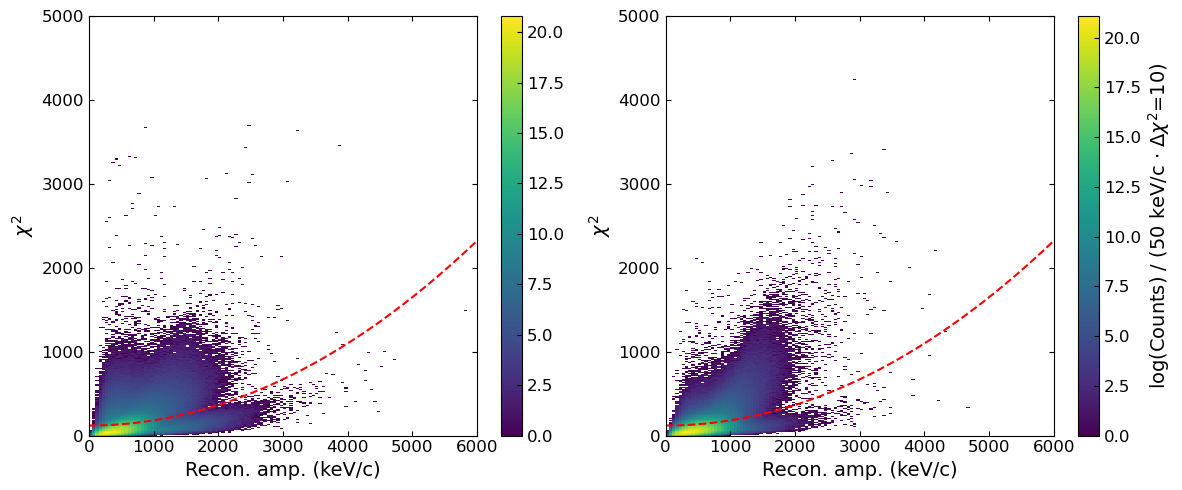

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

pc0 = axes[0].pcolormesh(bins_amp, bins_chi2, np.log(hh_amp_chi2_all_0.T))
pc1 = axes[1].pcolormesh(bins_amp, bins_chi2, np.log(hh_amp_chi2_all_1.T))

a, b = 120, 2200/(6000**2)
xx = np.linspace(0, 6000, 500)
for ax in axes:
    ax.plot(xx, a + b*xx**2, 'r--')

for ax in axes:
    ax.set_xlabel('Recon. amp. (keV/c)')
    ax.set_ylabel(r'$\chi^2$')
    ax.set_ylim(0, 5000)
    ax.set_xlim(0, 6000)

cbar0 = fig.colorbar(pc0)
cbar1 = fig.colorbar(pc1)
for cbar in [cbar1]:
    cbar.set_label(r'log(Counts) / (50 keV/c $\cdot$ $\Delta \chi^2$=10)')

fig.tight_layout()


In [61]:
sphere = sphere_0
amp2kev_0 = 7187.368332843102

large_chi2_0, large_waveforms_0 = [], []
for dataset in datasets_0:
    f = h5py.File(fr"E:\dm_data_processed_amp_chisquare\{sphere}\{dataset}\{dataset}_large_pulse_waveforms.hdf5", 'r')
    pulse_amp = f['pulses']['pulse_amp'][:]
    waveforms = f['pulses']['pulse_waveform'][:]
    pulse_chi2 = f['pulses']['pulse_chi2'][:]
    f.close()

    large_pulse = np.abs(pulse_amp) * amp2kev_0 > 3000
    if np.sum(large_pulse) == 0:
        continue
    else:
        large_chi2_0.append(pulse_chi2[large_pulse])
        large_waveforms_0.append(waveforms[large_pulse])

large_chi2_0 = np.concatenate(large_chi2_0, axis=0)
large_waveforms_0 = np.concatenate(large_waveforms_0, axis=0)

In [63]:
large_chi2_0.shape

(128,)

<>:14: SyntaxWarning: invalid escape sequence '\c'
<>:14: SyntaxWarning: invalid escape sequence '\c'
C:\Users\yuhan\AppData\Local\Temp\ipykernel_3180\2175844181.py:14: SyntaxWarning: invalid escape sequence '\c'
  ax.text(-0.075, 3000, f'$\chi^2$ = {large_chi2_0[i]:.2f}', fontsize=12)


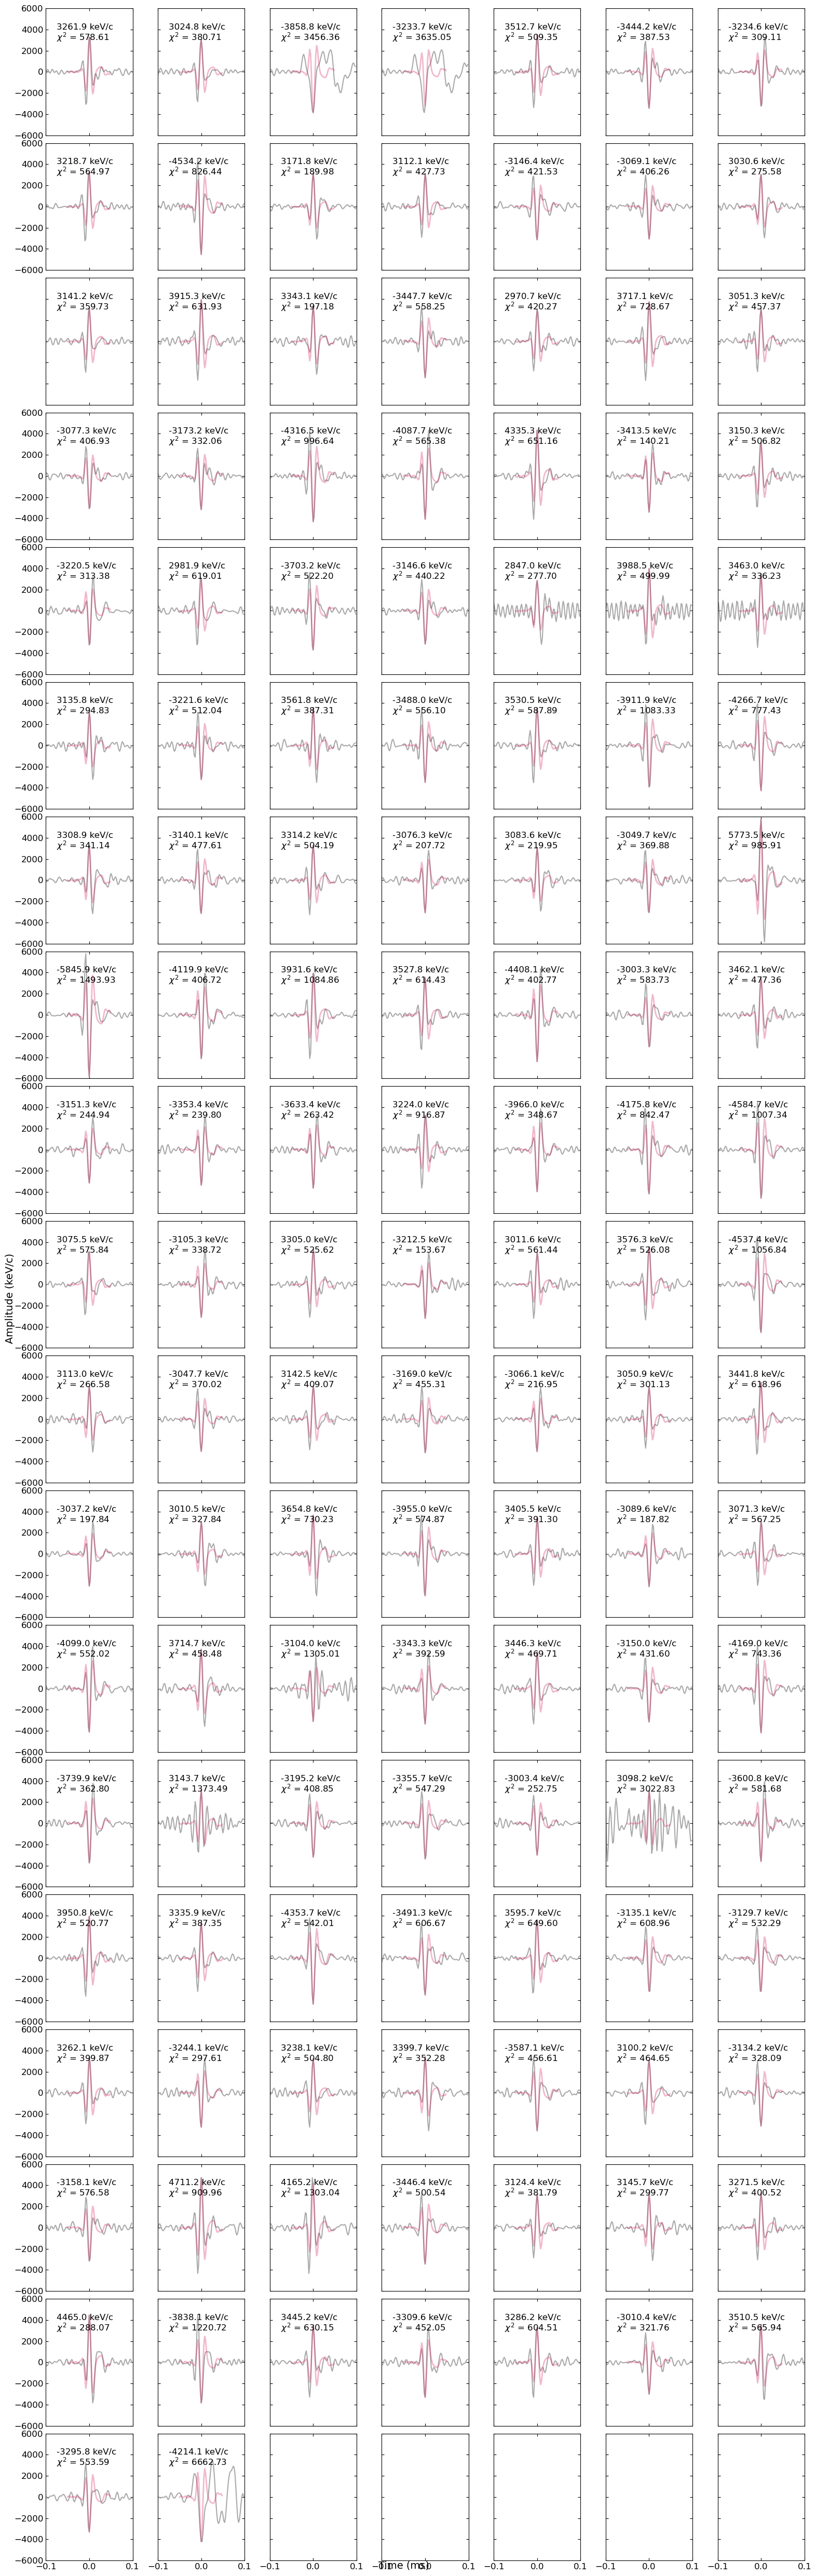

In [64]:
fig, axes = plt.subplots(19, 7, figsize=(16, 50))

normalized_template_downsampled_short = get_normalized_template('sphere_20250103', voltage=20, bounds=(1250, 1750), downsampled=True)

for i, waveform in enumerate(large_waveforms_0):
    ax = axes.flatten()[i]

    tt = np.arange(-50, 50) * 2e-3
    tt_template = np.arange(-25, 25) * 2e-3

    ax.plot(tt, waveform * amp2kev_0, color='darkgrey')
    ax.plot(tt_template, normalized_template_downsampled_short * waveform[50] * amp2kev_0, color='#D41159', alpha=0.3, linewidth=2)
    ax.text(-0.075, 4000, f'{waveform[50] * amp2kev_0:.1f} keV/c', fontsize=12)
    ax.text(-0.075, 3000, f'$\chi^2$ = {large_chi2_0[i]:.2f}', fontsize=12)

    if i % 7 != 0:
        ax.set_yticklabels('') 
    if i < 7*18:
        ax.set_xticklabels('')

for i in range(5):
    axes.flatten()[-1*i-1].set_yticklabels('')

for ax in axes.flatten():
    ax.set_xlim(-0.1, 0.1)
    ax.set_ylim(-6000, 6000)

axes.flatten()[14].set_yticklabels('')

fig.supxlabel('Time (ms)', fontsize=14)
fig.supylabel('Amplitude (keV/c)', fontsize=14)

fig.tight_layout()

In [48]:
sphere = sphere_1

large_chi2_1, large_waveforms_1 = [], []
for dataset in datasets_1:
    f = h5py.File(fr"E:\dm_data_processed_amp_chisquare\{sphere}\{dataset}\{dataset}_large_pulse_waveforms.hdf5", 'r')
    pulse_amp = f['pulses']['pulse_amp'][:]
    waveforms = f['pulses']['pulse_waveform'][:]
    pulse_chi2 = f['pulses']['pulse_chi2'][:]
    f.close()

    large_pulse = np.abs(pulse_amp) * amp2kev > 3000
    if np.sum(large_pulse) == 0:
        continue
    else:
        large_chi2_1.append(pulse_chi2[large_pulse])
        large_waveforms_1.append(waveforms[large_pulse])

large_chi2_1 = np.concatenate(large_chi2_1, axis=0)
large_waveforms_1 = np.concatenate(large_waveforms_1, axis=0)

<>:14: SyntaxWarning: invalid escape sequence '\c'
<>:14: SyntaxWarning: invalid escape sequence '\c'
C:\Users\yuhan\AppData\Local\Temp\ipykernel_3180\2828963275.py:14: SyntaxWarning: invalid escape sequence '\c'
  ax.text(-0.075, 3000, f'$\chi^2$ = {large_chi2_1[i]:.2f}', fontsize=12)


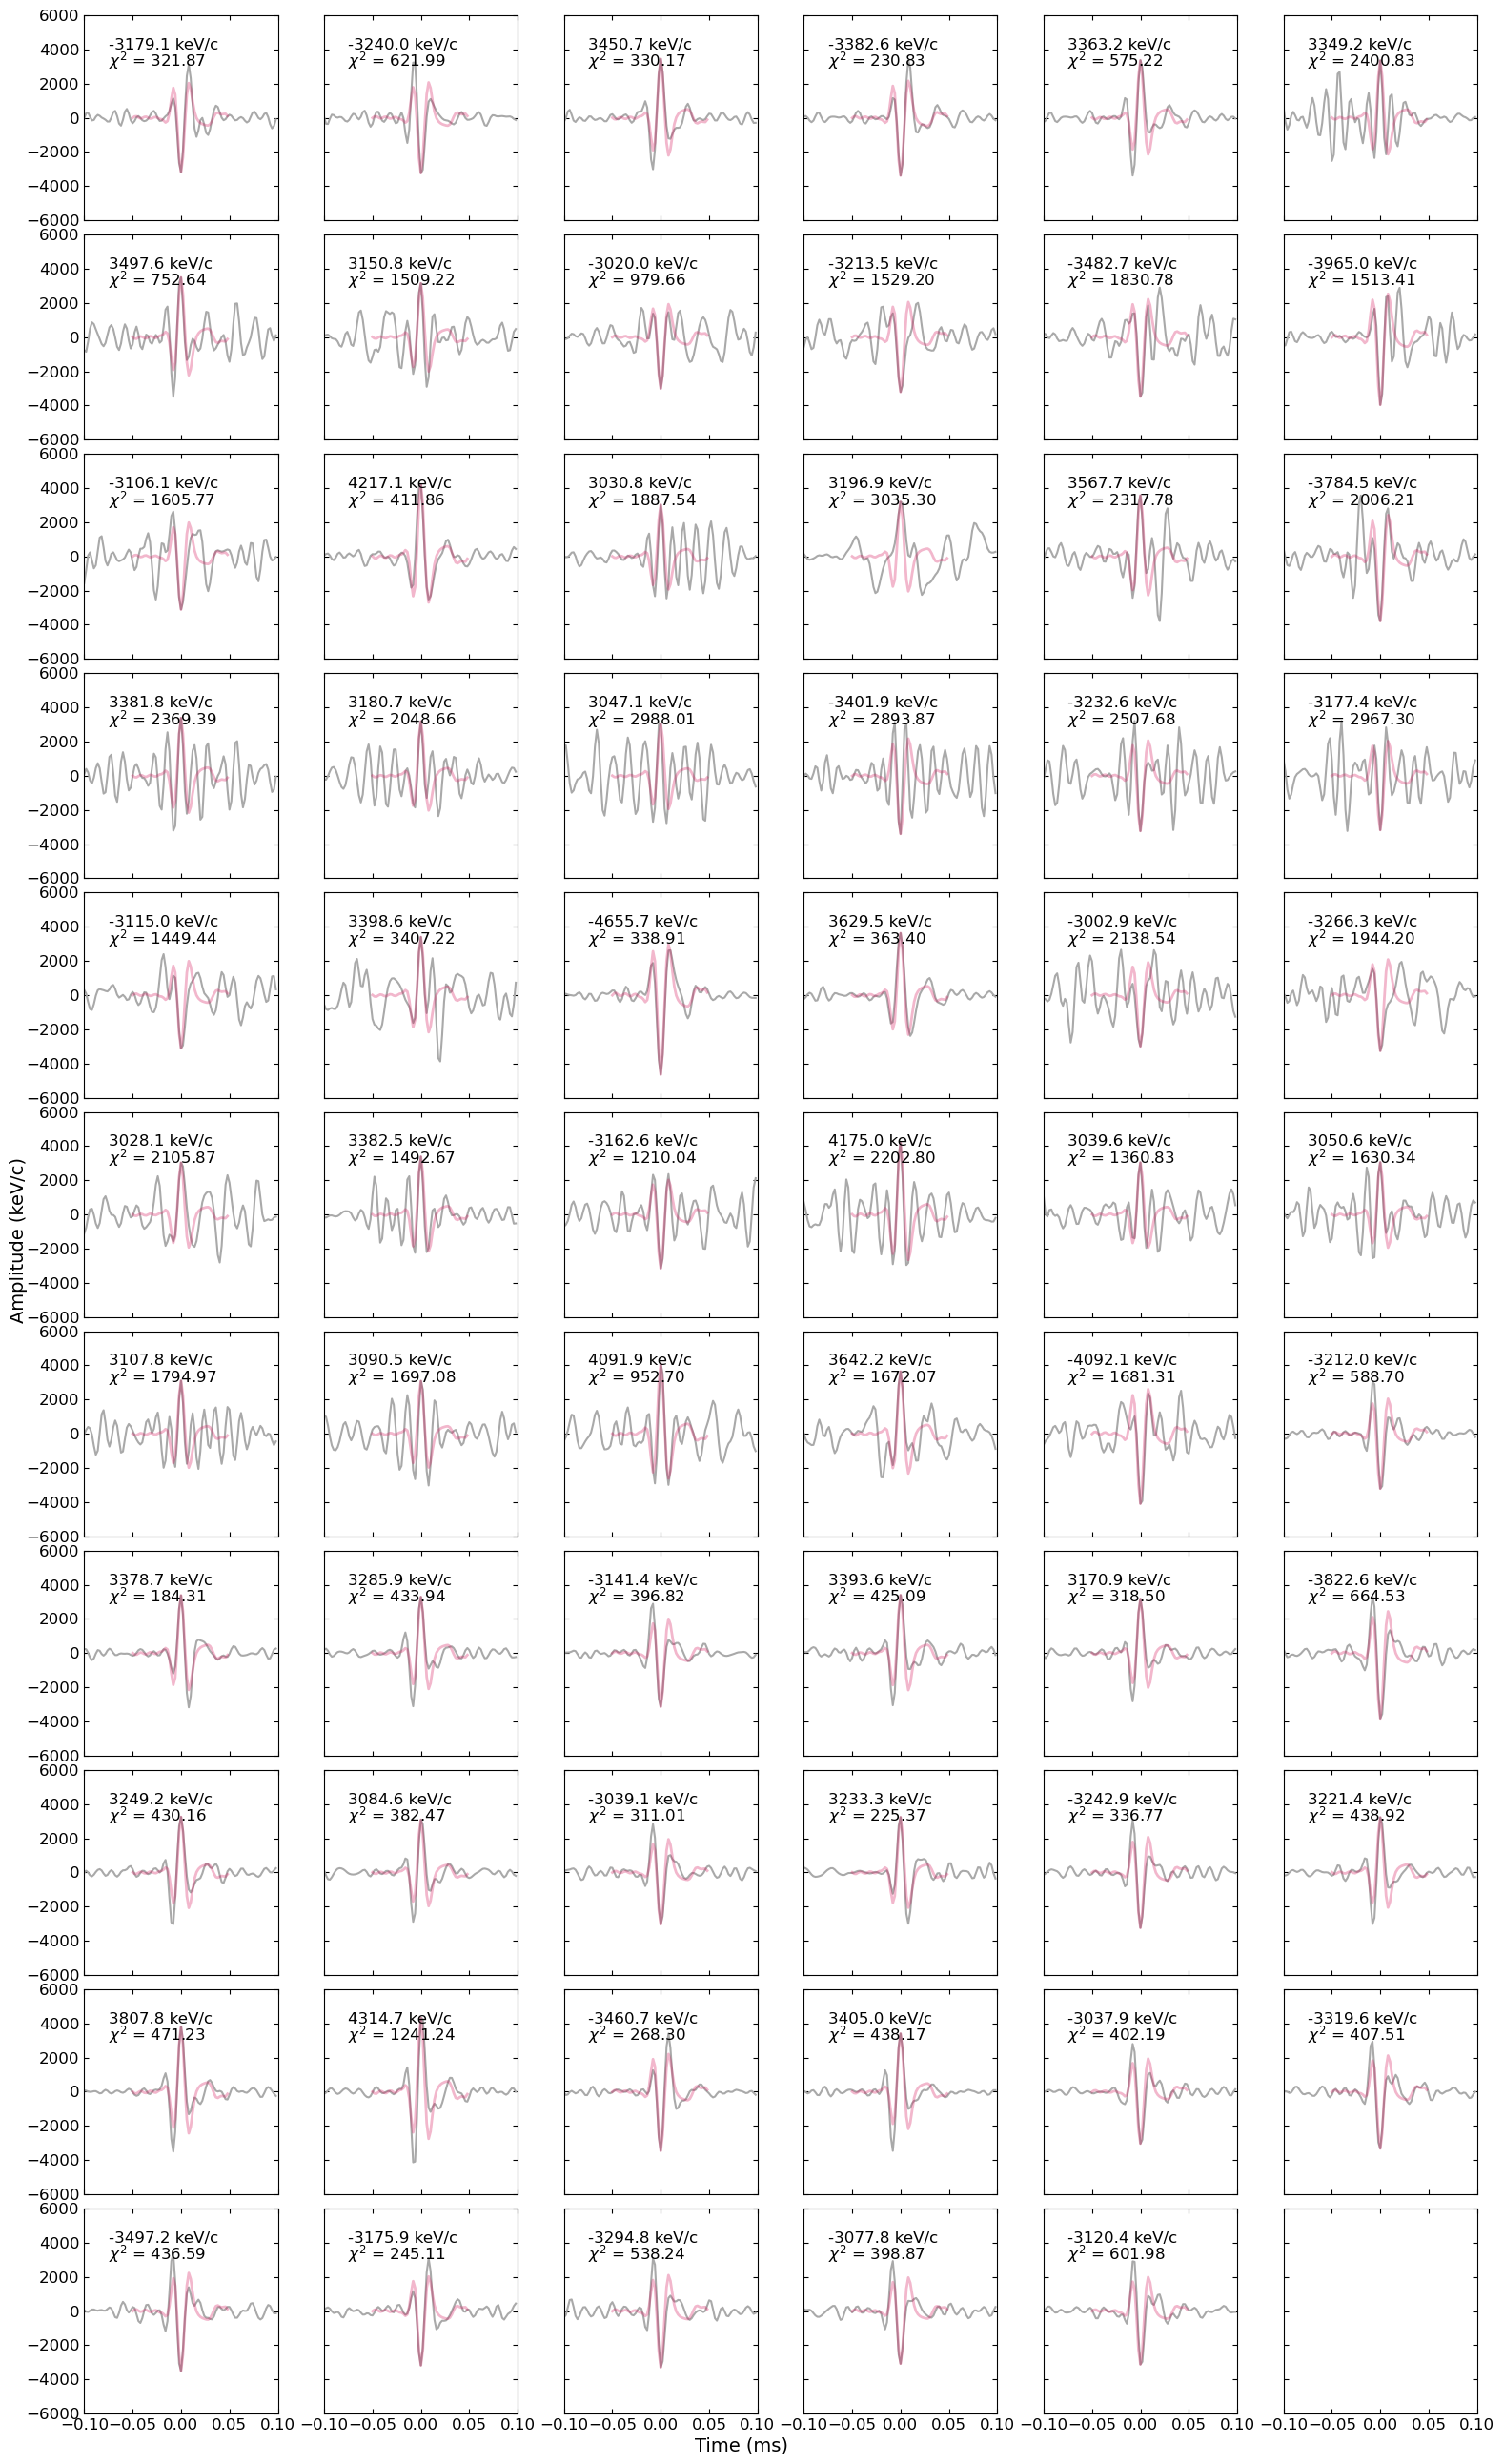

In [49]:
fig, axes = plt.subplots(11, 6, figsize=(16, 26))

normalized_template_downsampled_short = get_normalized_template('sphere_20250103', voltage=20, bounds=(1250, 1750), downsampled=True)

for i, waveform in enumerate(large_waveforms_1):
    ax = axes.flatten()[i]

    tt = np.arange(-50, 50) * 2e-3
    tt_template = np.arange(-25, 25) * 2e-3

    ax.plot(tt, waveform * amp2kev, color='darkgrey')
    ax.plot(tt_template, normalized_template_downsampled_short * waveform[50] * amp2kev, color='#D41159', alpha=0.3, linewidth=2)
    ax.text(-0.075, 4000, f'{waveform[50] * amp2kev:.1f} keV/c', fontsize=12)
    ax.text(-0.075, 3000, f'$\chi^2$ = {large_chi2_1[i]:.2f}', fontsize=12)

    if i % 6 != 0:
        ax.set_yticklabels('') 
    if i < 60:
        ax.set_xticklabels('')

axes.flatten()[-1].set_yticklabels('')

for ax in axes.flatten():
    ax.set_xlim(-0.1, 0.1)
    ax.set_ylim(-6000, 6000)

axes.flatten()[14].set_yticklabels('')

# fig.suptitle('20250114_1e-8mbar_1e_alignment1_long', fontsize=14)
fig.supxlabel('Time (ms)', fontsize=14)
fig.supylabel('Amplitude (keV/c)', fontsize=14)

fig.tight_layout()

In [10]:
sphere = sphere_1
dataset = datasets_1[0]
f = h5py.File(fr"E:\dm_data_processed_amp_chisquare\{sphere}\{dataset}\{dataset}_large_pulse_waveforms.hdf5", 'r')
waveforms = f['pulses']['pulse_waveform'][:]
pulse_chi2 = f['pulses']['pulse_chi2'][:]
f.close()

<>:14: SyntaxWarning: invalid escape sequence '\c'
<>:14: SyntaxWarning: invalid escape sequence '\c'
C:\Users\yuhan\AppData\Local\Temp\ipykernel_3180\4082313573.py:14: SyntaxWarning: invalid escape sequence '\c'
  ax.text(-0.075, 3000, f'$\chi^2$ = {pulse_chi2[i]:.2f}', fontsize=12)


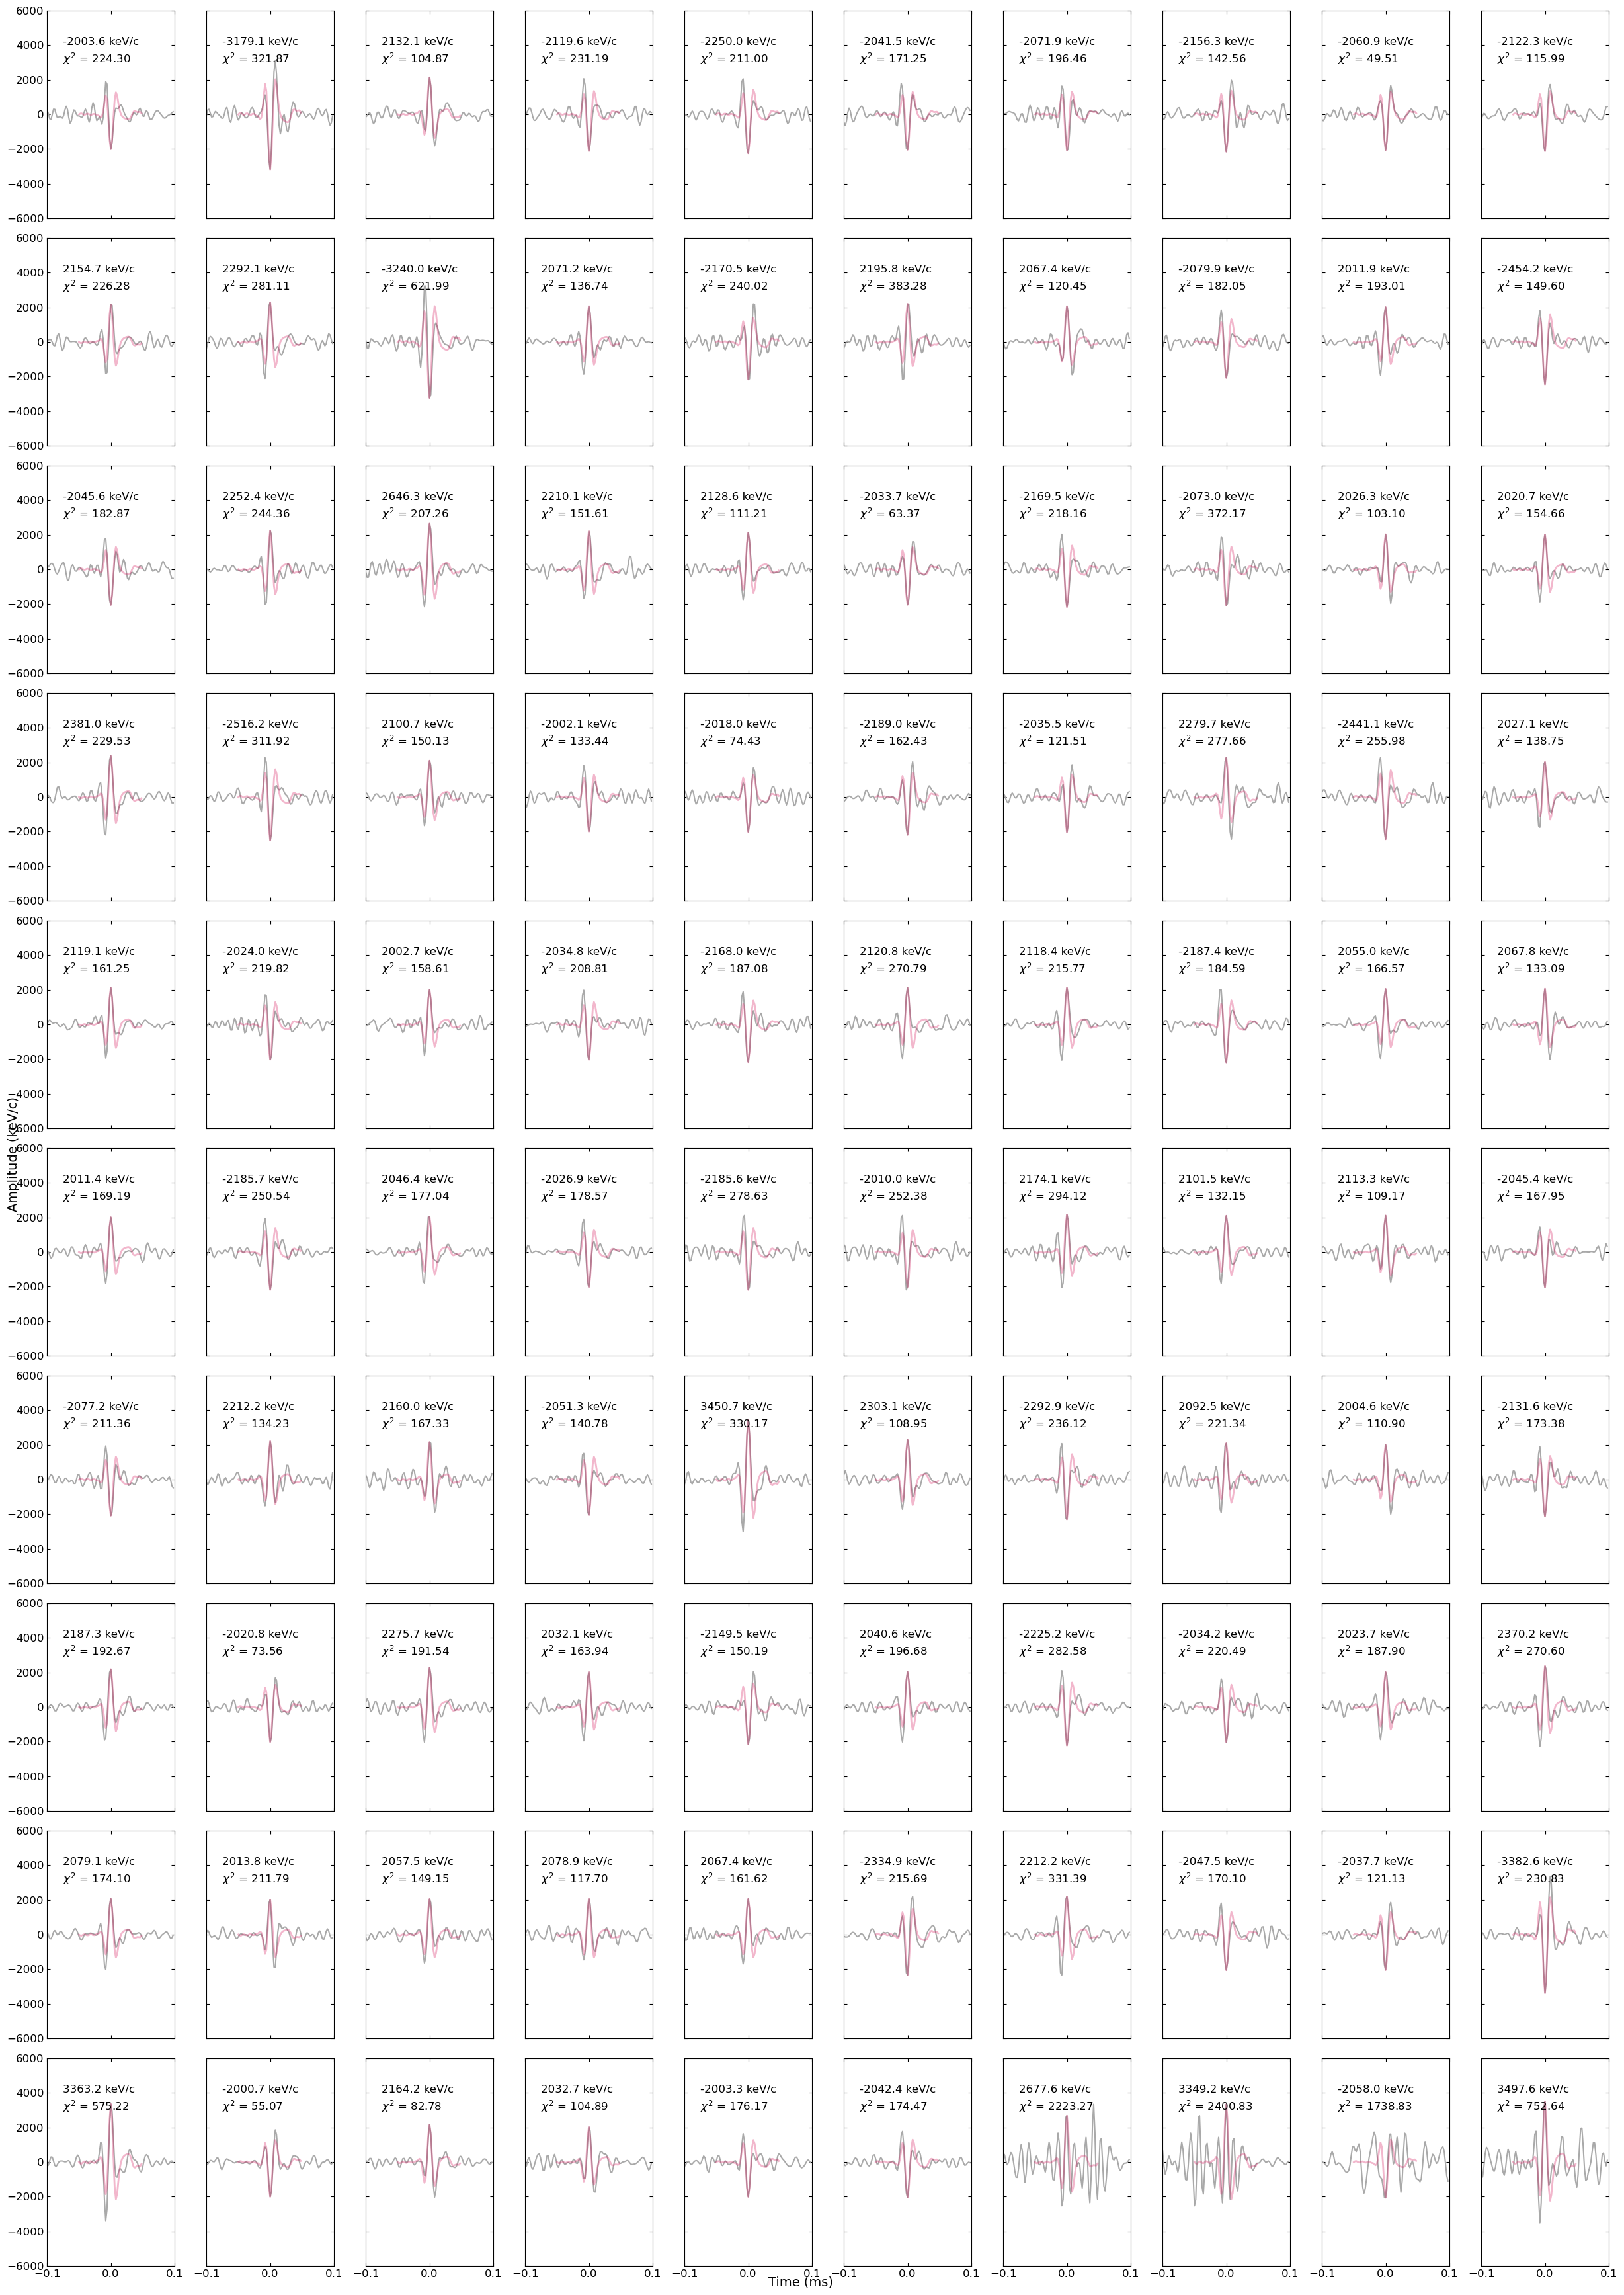

In [ ]:
fig, axes = plt.subplots(10, 10, figsize=(25, 35))

normalized_template_downsampled_short = get_normalized_template('sphere_20250103', voltage=20, bounds=(1250, 1750), downsampled=True)

for i, waveform in enumerate(waveforms[:100]):
    ax = axes.flatten()[i]

    tt = np.arange(-50, 50) * 2e-3
    tt_template = np.arange(-25, 25) * 2e-3

    ax.plot(tt, waveform * amp2kev, color='darkgrey')
    ax.plot(tt_template, normalized_template_downsampled_short * waveform[50] * amp2kev, color='#D41159', alpha=0.3, linewidth=2)
    ax.text(-0.075, 4000, f'{waveform[50] * amp2kev:.1f} keV/c', fontsize=12)
    ax.text(-0.075, 3000, f'$\chi^2$ = {pulse_chi2[i]:.2f}', fontsize=12)

    if i % 10 != 0:
        ax.set_yticklabels('') 
    if i < 90:
        ax.set_xticklabels('')

for ax in axes.flatten():
    ax.set_xlim(-0.1, 0.1)
    ax.set_ylim(-6000, 6000)

axes.flatten()[14].set_yticklabels('')

# fig.suptitle('20250114_1e-8mbar_1e_alignment1_long', fontsize=14)
fig.supxlabel('Time (ms)', fontsize=14)
fig.supylabel('Amplitude (keV/c)', fontsize=14)

fig.tight_layout()

In [8]:
f = h5py.File(r"E:\dm_data_processed_amp_chisquare\sphere_20250103\20250114_1e-8mbar_1e_alignment1_long\20250114_1e-8mbar_1e_alignment1_long_large_pulse_waveforms.hdf5", 'r')
waveforms = f['pulses']['pulse_waveform'][:]
pulse_chi2 = f['pulses']['pulse_chi2'][:]
f.close()

<>:13: SyntaxWarning: invalid escape sequence '\c'
<>:13: SyntaxWarning: invalid escape sequence '\c'
C:\Users\yuhan\AppData\Local\Temp\ipykernel_3180\1512879148.py:13: SyntaxWarning: invalid escape sequence '\c'
  ax.text(-0.075, 4000, f'$\chi^2$ = {pulse_chi2[i]:.2f}', fontsize=12)


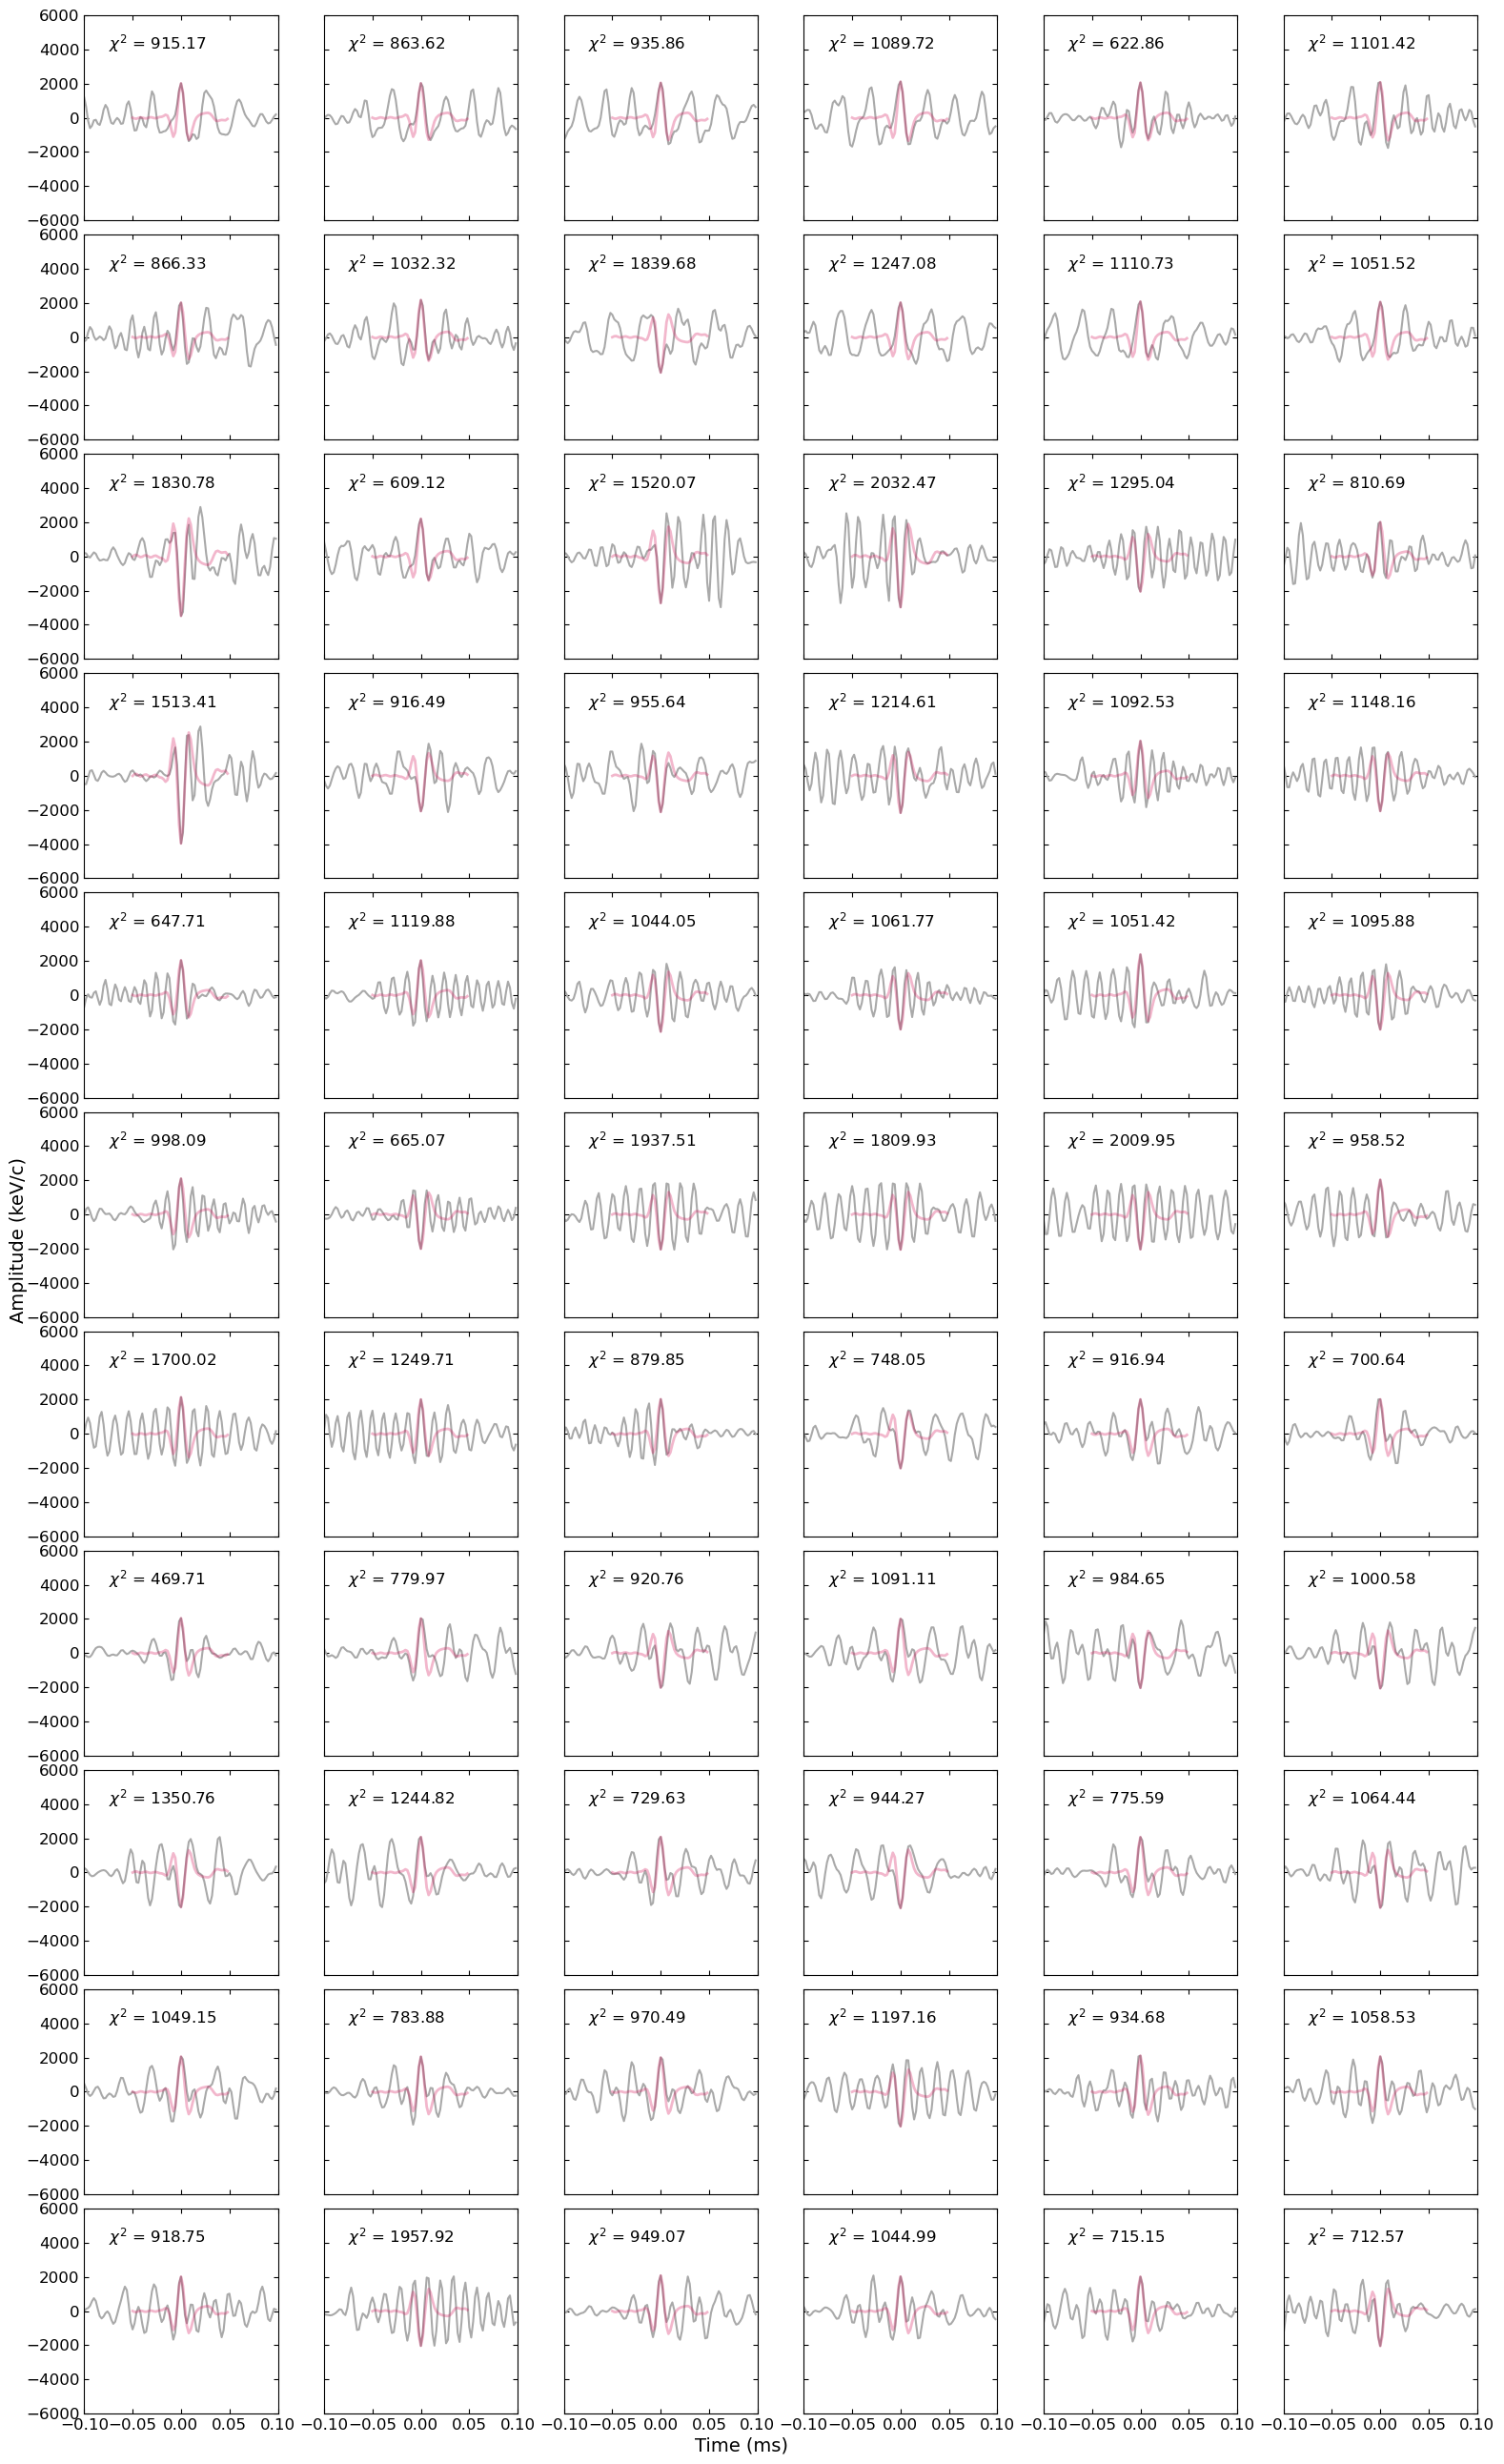

In [9]:
fig, axes = plt.subplots(11, 6, figsize=(16, 26))

normalized_template_downsampled_short = get_normalized_template('sphere_20250103', voltage=20, bounds=(1250, 1750), downsampled=True)

for i, waveform in enumerate(waveforms[:66]):
    ax = axes.flatten()[i]

    tt = np.arange(-50, 50) * 2e-3
    tt_template = np.arange(-25, 25) * 2e-3

    ax.plot(tt, waveform * amp2kev, color='darkgrey')
    ax.plot(tt_template, normalized_template_downsampled_short * waveform[50] * amp2kev, color='#D41159', alpha=0.3, linewidth=2)
    ax.text(-0.075, 4000, f'$\chi^2$ = {pulse_chi2[i]:.2f}', fontsize=12)

    if i % 6 != 0:
        ax.set_yticklabels('') 
    if i < 60:
        ax.set_xticklabels('')

    # ax.set_title(f'File {idx_file}, Window {idx_window}', fontsize=12)

for ax in axes.flatten():
    ax.set_xlim(-0.1, 0.1)
    ax.set_ylim(-6000, 6000)

axes.flatten()[14].set_yticklabels('')

# fig.suptitle('20250114_1e-8mbar_1e_alignment1_long', fontsize=14)
fig.supxlabel('Time (ms)', fontsize=14)
fig.supylabel('Amplitude (keV/c)', fontsize=14)

fig.tight_layout()

In [66]:
f = h5py.File(fr'E:\dm_data_processed_amp_chisquare\sphere_20250103\20250104_4e-8mbar_alignment0_long\20250104_d_0_processed.hdf5', 'r')
amplitude = f['data_processed']['amplitude'][:]
idx_in_window = f['data_processed']['idx_in_window'][:]
good_detection = f['data_processed']['good_detection'][:]
noise_level_amp = f['data_processed']['noise_level_amp'][:]
chisquare_short = f['data_processed']['chisquare_short'][:]

f.close()

In [73]:
amplitude * amp2kev

array([[ 690.54169546, -560.85070659, -271.60443083, ..., -691.63741866,
        -621.16951241, -434.62246252],
       [-256.54150917, -377.14003871, -487.87019861, ..., -585.77483749,
         317.07284887,  484.61760365],
       [ 288.46158766, -352.77599227,  290.25515919, ..., -248.16515871,
        -309.2847591 ,  371.5529482 ],
       ...,
       [ 389.5976208 , -393.7894766 ,  309.27462303, ..., -513.99708212,
         473.63317056, -295.08042395],
       [ 390.76182786,  473.6880555 , -355.00765279, ..., -265.80936207,
        -355.49518632,  484.55836484],
       [ 373.63475481, -292.02388365, -291.6742226 , ..., -442.53327328,
         421.15217961,  494.65981185]], shape=(6000, 194))

In [75]:
(120 + 0.1*(amplitude*amp2kev)**2)

array([[47804.78331655, 31575.35150835,  7496.89668484, ...,
        47956.23188886, 38705.15631538, 19009.66849248],
       [ 6701.35459292, 14343.46088015, 23921.73306903, ...,
        34433.21602387, 10173.51914886, 23605.42217701],
       [ 8441.00875527, 12565.09007227,  8544.80574388, ...,
         6278.59459961,  9685.70622126, 13925.15933195],
       ...,
       [15298.63061306, 15627.01518848,  9685.07924476, ...,
        26539.30004248, 22552.83802594,  8827.24565983],
       [15389.48061127, 22558.0373925 , 12723.04335417, ...,
         7185.46169639, 12757.68274938, 23599.68089397],
       [14080.29300022,  8647.79486216,  8627.38521268, ...,
        19703.56979601, 17856.91583881, 24588.8329456 ]],
      shape=(6000, 194))

In [82]:
bins_amp  = np.arange(0, 10000, 50)
bins_chi2 = np.arange(0, 10000, 10)

hh, xe, ye = np.histogram2d(x=np.abs(amp_all[0].flatten()) * amp2kev, y=chi2_all[0].flatten(),
                            bins=[bins_amp, bins_chi2])

In [84]:
hh

array([[  0.,   0.,   0., ...,   0.,   0.,   0.],
       [  3.,   9.,   3., ...,   0.,   0.,   0.],
       [ 30., 299., 378., ...,   0.,   0.,   0.],
       ...,
       [  0.,   0.,   0., ...,   0.,   0.,   0.],
       [  0.,   0.,   0., ...,   0.,   0.,   0.],
       [  0.,   0.,   0., ...,   0.,   0.,   0.]], shape=(199, 999))

In [40]:
hh.shape

(199, 999)

In [47]:
X.shape

(200, 1000)

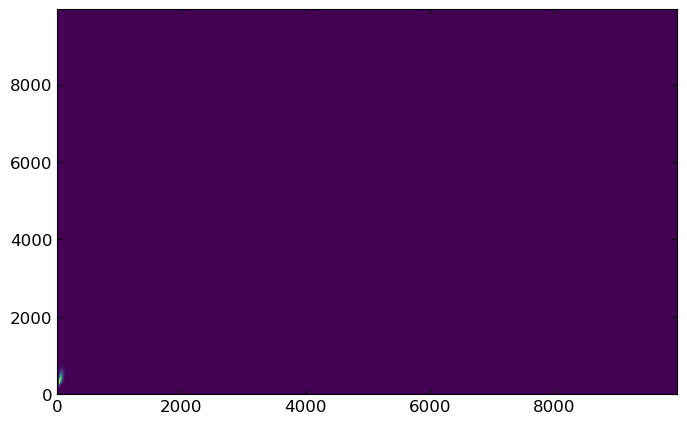

In [46]:
X, Y = np.meshgrid(ye, xe)

fig, ax = plt.subplots(figsize=(8, 5))
ax.pcolormesh(X, Y, hh)
# ax.set_xlim(0, 2000)
# ax.set_ylim(0, 1000)

Text(0, 0.5, '$\\chi^2$')

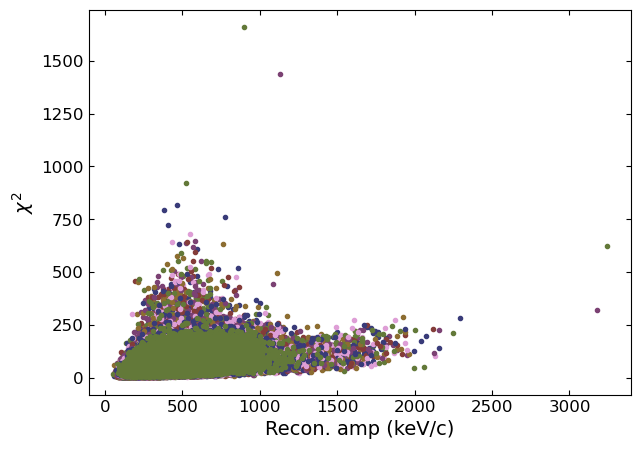

In [ ]:
for i in range(50):
    plt.plot(np.abs(amp_all[i].flatten()) * amp2kev, chi2_all[i].flatten(), '.')

plt.xlabel('Recon. amp (keV/c)')
plt.ylabel(r'$\chi^2$')

In [35]:
idx_file, idx_window = 733, 1403

window_length = 5000
f = h5py.File(f'/Users/yuhan/work/nanospheres/data/dm_data/sphere_20250103/20250114_1e-8mbar_1e_alignment1_long/20250114_d_{idx_file}.hdf5', 'r')

dtt = f['data'].attrs['delta_t']
fs = int(np.ceil(1 / dtt))   # Sampling rate at Hz
zz = f['data']['channel_d'][:] * f['data']['channel_d'].attrs['adc2mv'] / 1e3  # Signal in V
f.close()

zz_bp = utils.bandpass_filtered(zz, fs, 30000, 80000)
zz_bp_shaped = np.reshape(zz_bp, (int(zz_bp.size / window_length), window_length))

_zz_bp = zz_bp_shaped[idx_window]
_amp, amp_lp, temp = utils.recon_force(dtt, _zz_bp, c_mv=None)

idx_pulse = np.argmax(np.abs(amp_lp[100:-50])) + 100

In [36]:
def get_normalized_template(sphere, voltage, bounds=(1000, 2000), downsampled=False):
    pulse_shape_file = np.load(rf'/Users/yuhan/work/nanospheres/dm_nanospheres/data_processed/pulse_shape/{sphere}_pulse_shape_template_{voltage}v.npz')
    pulse_shapes = pulse_shape_file['pulse_shape']
    pulse_shape_template = np.mean(pulse_shapes, axis=0)

    normalized_template = pulse_shape_template / np.max(pulse_shape_template)

     # Take the central values around the peak
    ret = normalized_template[bounds[0]:bounds[1]]

    # Downsample to 500 kHz (so the 200 us template has 100 indices)
    if downsampled:
        ret_downsampled = decimate(ret, 10)
        return ret_downsampled / np.max(ret_downsampled)
    else:
        return ret

normalized_template_downsampled_short = get_normalized_template('sphere_20250103', voltage=20, bounds=(1250, 1750), downsampled=True)


In [37]:
template_scaled = normalized_template_downsampled_short * amp_lp[idx_pulse]

In [38]:
n_realization = 20000
noise = np.random.normal(0, sigma_amp, 50*n_realization)
noise = noise.reshape(n_realization, 50)

In [39]:
chi2 = np.empty(n_realization)
for i in range(n_realization):
    waveform = amp_lp[idx_pulse-25:idx_pulse+25] + noise[i]
    chi2[i] = np.sum( ((waveform - template_scaled)/sigma_amp)**2 )

In [43]:
626.94 / amp_lp[idx_pulse]

-922.1995256295266

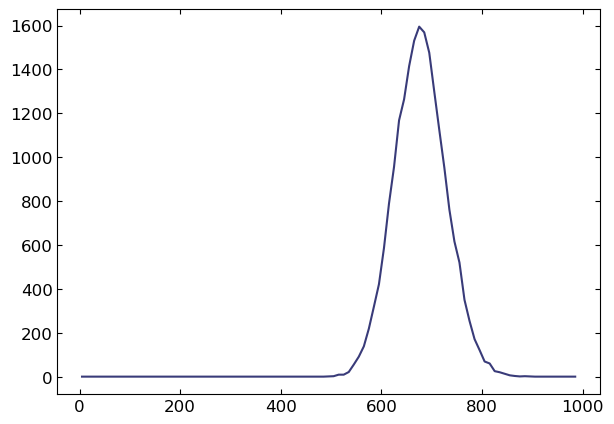

In [40]:
bins = np.arange(0, 1000, 10)
bc = 0.5 * (bins[1:] + bins[:-1])

hh, _ = np.histogram(chi2, bins)
plt.plot(bc, hh)

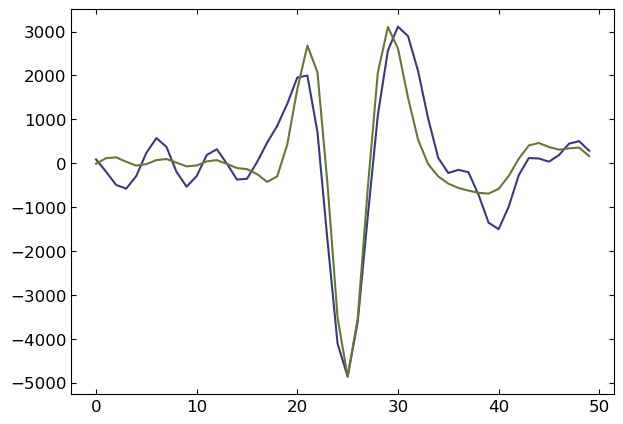

In [41]:
plt.plot(amp_lp[idx_pulse-25:idx_pulse+25] * amp2kev)
plt.plot(normalized_template_downsampled_short * amp_lp[idx_pulse] * amp2kev)